# Визуализация траекторий агентов

В ноутбуке выполняется серия эпизодов (DQN + baselines), записываются
траектории и рисуются графики из `src.evaluation.trajectory_visualizer`.

In [15]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import torch

from src import api
from src.evaluation.trajectory_visualizer import (
    dump_trajectories_csv,
    plot_coverage_and_novelty,
    plot_reward_trajectories,
)
from src.utils.helpers import get_device, set_seed

DATASET = "oulad"  # "itmrec" или "oulad"
N_USERS = 8
TRAJECTORY_LEN = 50


def _find_latest_checkpoint(root: Path, dataset: str, kind: str) -> Path | None:
    """Ищет последний чекпоинт ``deepfm_<dataset>_best.pth`` / ``dqn_<dataset>_*.pth``.

    Поиск ведётся сначала в ``results/**/models/`` (куда сохраняет API),
    затем как fallback в ``data/models/`` (старый путь).
    """
    pattern = f"{kind}_{dataset}_best.pth"
    candidates = list((root / "results").glob(f"**/models/{pattern}"))
    if kind == "dqn":
        candidates += list((root / "results").glob(f"**/models/dqn_{dataset}_checkpoint.pth"))
        candidates += list((root / "results").glob(f"**/models/dqn_{dataset}_final.pth"))
    fallback = root / "data" / "models" / pattern
    if fallback.exists():
        candidates.append(fallback)
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)


DEEPFM_CKPT = _find_latest_checkpoint(ROOT, DATASET, "deepfm")
DQN_CKPT = _find_latest_checkpoint(ROOT, DATASET, "dqn")

if DEEPFM_CKPT is None:
    raise FileNotFoundError(
        f"Не найден чекпоинт deepfm_{DATASET}_best.pth. "
        f"Запустите сначала notebooks/00_quickstart.ipynb или notebooks/06_hypotheses.ipynb, "
        f"чтобы обучить модели."
    )
if DQN_CKPT is None:
    raise FileNotFoundError(
        f"Не найден чекпоинт dqn_{DATASET}. Запустите обучение DQN."
    )

print("DeepFM checkpoint:", DEEPFM_CKPT)
print("DQN    checkpoint:", DQN_CKPT)

set_seed(42)
device = get_device()
print("device:", device)

FileNotFoundError: Не найден чекпоинт deepfm_oulad_best.pth. Запустите сначала notebooks/00_quickstart.ipynb или notebooks/06_hypotheses.ipynb, чтобы обучить модели.

In [7]:
config = api.build_config(DATASET, yaml_path=str(ROOT / "configs" / f"{DATASET}.yaml"))
run_dir = api.prepare_run(config, run_name=f"{DATASET}_trajectories")
bundle = api.load_dataset_bundle(DATASET, config=config)
deepfm_model, _ = api.load_static_model(DEEPFM_CKPT, device=device)

if DATASET == "itmrec":
    from src.environment.educational_env import EducationalEnvironment
    env = EducationalEnvironment(
        bundle.ratings, bundle.users, bundle.items,
        deepfm_model, bundle.metadata.get("dataset_object"),
        config=config.get("environment", {}),
    )
else:
    from src.environment.oulad_env import OULADEnvironment
    env = OULADEnvironment(bundle, deepfm_model, config=config.get("environment", {}))

state_dim = config.get("model", {}).get("dqn", {}).get("state_dim")
hidden_dims = config.get("model", {}).get("dqn", {}).get("hidden_dims", [256, 128, 64])
action_dim = env.dataset.n_items

dqn = api._load_dqn_checkpoint(DQN_CKPT, state_dim, action_dim, hidden_dims, device=device)
print("state_dim:", state_dim, "| action_dim:", action_dim)

2026-04-24 02:49:42 | INFO | rec_sys_edu | Запуск: results\itmrec_trajectories_20260424_024942
2026-04-24 02:49:42 | INFO | rec_sys_edu | Processed-данные не найдены, пытаемся загрузить raw
Загрузка датасета irecsys/itmrec с Kaggle...
Датасет загружен в: C:\Users\Nasty\.cache\kagglehub\datasets\irecsys\itmrec\versions\3
ЗАГРУЗКА ДАТАСЕТА ITM-REC
Загружено 5230 записей рейтингов
Загружено 476 пользователей
Загружено 70 предметов

Размеры загруженных таблиц:
- ratings: (5230, 9)
- users: (476, 4)
- items: (70, 4)
Валидация данных пройдена успешно
2026-04-24 02:49:43 | INFO | rec_sys_edu | Cold-start filter: 5230 -> 5230 ratings (min_user=3, min_item=2)
Датасет инициализирован:
  Пользователей: 454
  Предметов: 70
  Классов: 3
  Семестров: 2
  Периодов COVID: 3
  Записей рейтингов: 5230
2026-04-24 02:49:43 | INFO | rec_sys_edu | ITM-Rec bundle готов: {'dataset_type': 'itmrec', 'n_users': 454, 'n_items': 70, 'state_dim': 65, 'n_ratings_rows': 5230, 'target_columns': ['Rating', 'App', 'Data

In [8]:
def rollout(env, policy, user_id: int, max_steps: int = TRAJECTORY_LEN):
    state = env.reset(user_id=int(user_id))
    actions, rewards = [], []
    for _ in range(max_steps):
        action = policy(state, env)
        next_state, reward, done, _ = env.step(int(action))
        actions.append(int(action))
        rewards.append(float(reward))
        state = next_state
        if done:
            break
    return {"user_id": int(user_id), "actions": actions, "rewards": rewards}


def dqn_policy(state, env):
    mask = env.get_action_mask() if hasattr(env, "get_action_mask") else None
    return int(dqn.get_action(state, epsilon=0.01, action_mask=mask))


def random_policy(state, env):
    return int(np.random.randint(0, env.dataset.n_items))


unique_users = bundle.ratings["UserID_encoded"].unique()
sample_users = np.random.choice(unique_users, min(N_USERS, len(unique_users)), replace=False)

trajectories_dqn = [rollout(env, dqn_policy, u) for u in sample_users]
trajectories_rand = [rollout(env, random_policy, u) for u in sample_users]
print("собрано траекторий:", len(trajectories_dqn), "+", len(trajectories_rand))

Эпизод начат: User 426, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 330, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 306, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 179, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 376, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 237, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 394, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 10, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 426, Context {'class': 1, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 330, Context {'class': 0, 'semester': 0, 'lockdown': 2}
Эпизод начат: User 306, Context {'class': 1, 'semester': 0, 'lockdown': 1}
Эпизод начат: User 179, Context {'class': 2, 'semester': 1, 'lockdown': 1}
Эпизод начат: User 376, Context {'class': 0, 'semester': 1, 'lockdown': 2}
Эпизод начат: User 237, Co

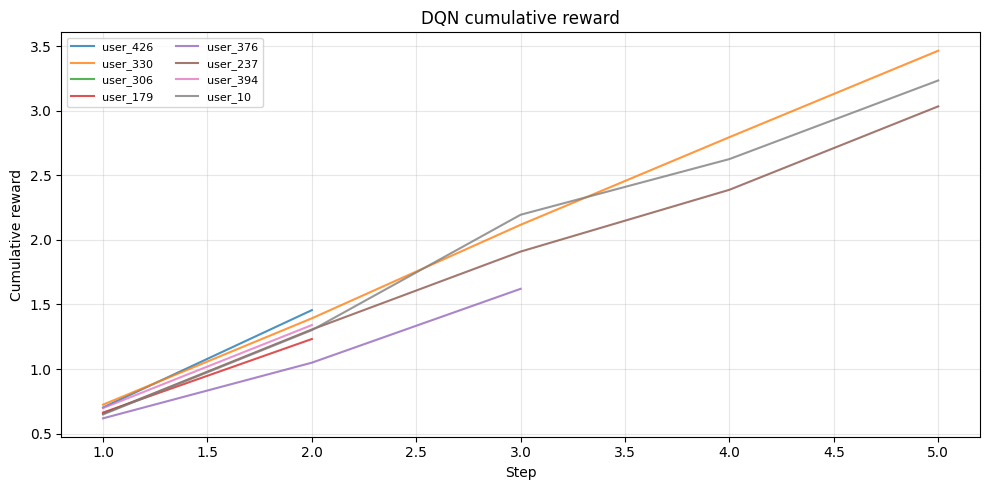

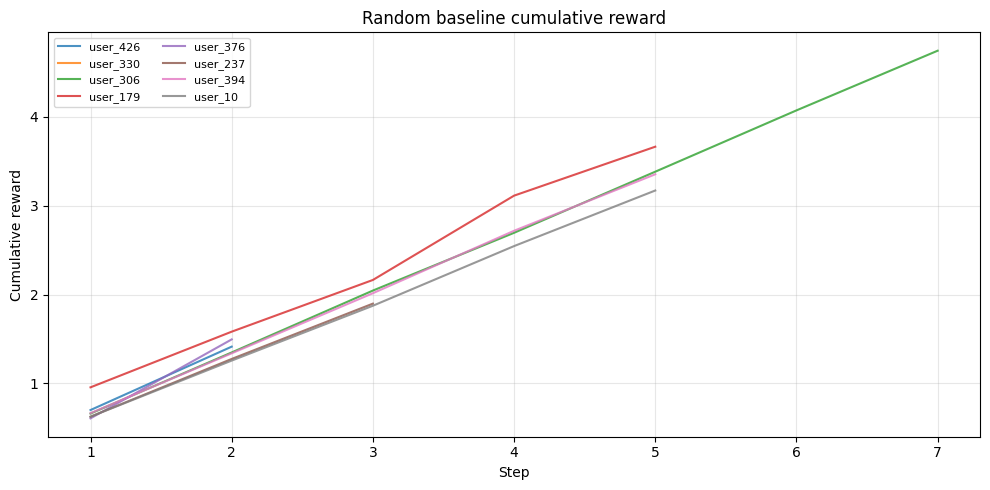

WindowsPath('results/itmrec_trajectories_20260424_024942/figures/trajectory_reward_random.png')

In [10]:
%matplotlib inline
fig_dir = Path(run_dir) / "figures"
tables_dir = Path(run_dir) / "tables"

plot_reward_trajectories(
    trajectories_dqn,
    labels=[f"user_{t['user_id']}" for t in trajectories_dqn],
    title="DQN cumulative reward",
    save_path=fig_dir / "trajectory_reward_dqn.png",
    show=True,
)
plot_reward_trajectories(
    trajectories_rand,
    labels=[f"user_{t['user_id']}" for t in trajectories_rand],
    title="Random baseline cumulative reward",
    save_path=fig_dir / "trajectory_reward_random.png",
    show=True,
)

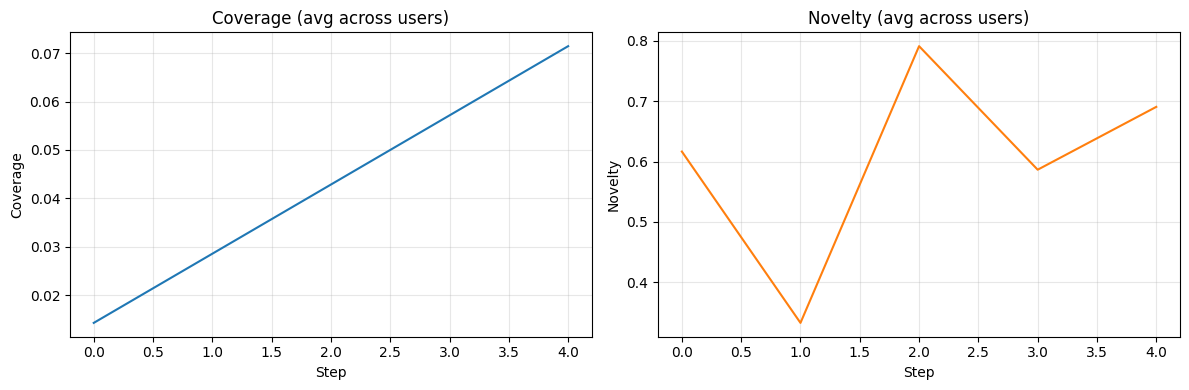

CSV сохранены: results\itmrec_trajectories_20260424_024942\tables


In [11]:
%matplotlib inline
item_popularity = bundle.ratings["ItemID_encoded"].value_counts().to_dict()

plot_coverage_and_novelty(
    trajectories_dqn,
    n_items=env.dataset.n_items,
    item_popularity=item_popularity,
    save_path=fig_dir / "coverage_novelty_dqn.png",
    show=True,
)

dump_trajectories_csv(trajectories_dqn, tables_dir / "trajectories_dqn.csv")
dump_trajectories_csv(trajectories_rand, tables_dir / "trajectories_random.csv")
print("CSV сохранены:", tables_dir)